In [ ]:
# import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

In [ ]:
# read data from csv files
train_df = pd.read_csv('D:/2025/Workspace/Vietnamese-Sentiment-Analysis/dataset/synthetic_train.csv')
val_df = pd.read_csv('D:/2025/Workspace/Vietnamese-Sentiment-Analysis/dataset/synthetic_val.csv')

In [8]:
print(train_df.shape)
print(val_df.shape)

(8144, 3)
(2036, 3)


In [ ]:
# show the first 5 rows of the training dataframe
train_df.head()

,sentence,sentiment,topic
0,Đội ngũ bảo trì quá thưa thớt dẫn đến không đả...,negative,facility
1,The university's musical and artistic faciliti...,neutral,facility
2,Phương pháp giảng dạy phù hợp với các đối tượn...,neutral,curriculum
3,Chương trình học giúp tôi trở thành một chuyên...,positive,curriculum
4,Tôi nghĩ rằng chương trình đào tạo có thể có t...,neutral,curriculum


In [10]:
print("DataFrame Info:")
print(train_df.info())

DataFrame Info:
<class 'pandas.DataFrame'>
RangeIndex: 8144 entries, 0 to 8143
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   sentence   8144 non-null   str  
 1   sentiment  8144 non-null   str  
 2   topic      8144 non-null   str  
dtypes: str(3)
memory usage: 1.0 MB
None


In [ ]:
# check for missing values
train_df.isnull().sum()

sentence     0
sentiment    0
topic        0
dtype: int64

In [ ]:
# check for duplicate rows
train_df.duplicated().sum()

np.int64(0)

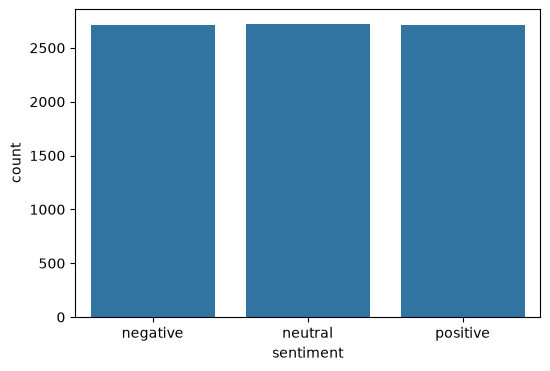

In [ ]:
# sentiment label distribution
train_df['sentiment'].value_counts()

plt.figure(figsize=(6,4))

sns.countplot(
    data=train_df,
    x='sentiment'
)
plt.savefig("../images/sentiment_distribution.png")
plt.show()


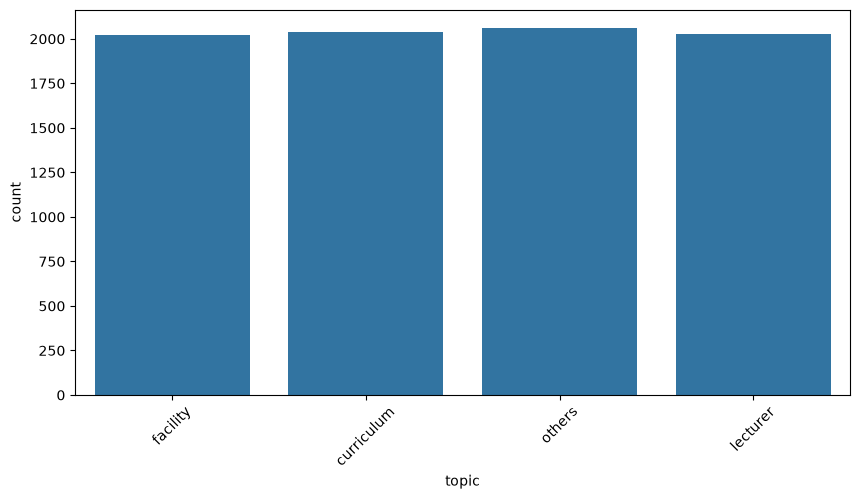

In [ ]:
# topic distribution
train_df['topic'].value_counts()

plt.figure(figsize=(10,5))

sns.countplot(
    data=train_df,
    x='topic'
)

plt.xticks(rotation=45)
plt.savefig("../images/topic_distribution.png")
plt.show()


In [ ]:
# sentence length distribution
train_df['length'] = train_df['sentence'].apply(len)

train_df['length'].describe()

count    8144.000000
mean       70.786223
std        22.295490
min        13.000000
25%        55.000000
50%        68.000000
75%        83.000000
max       190.000000
Name: length, dtype: float64

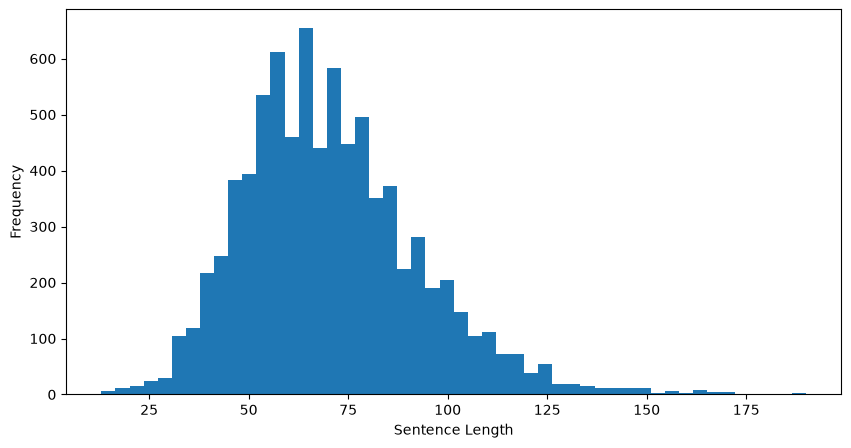

In [24]:
plt.figure(figsize=(10,5))

plt.hist(train_df['length'], bins=50)

plt.xlabel('Sentence Length')
plt.ylabel('Frequency')
plt.savefig("../images/sentence_length_distribution.png")
plt.show()


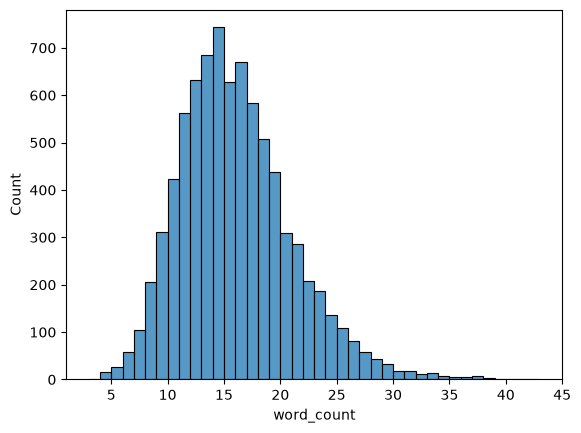

In [ ]:
# sentence word count distribution
train_df['word_count'] = train_df['sentence'].apply(lambda x: len(x.split()))

sns.histplot(train_df['word_count'], bins=40)

plt.show()

In [ ]:
# show some example sentences for each sentiment label
for label in train_df['sentiment'].unique():
    print(label)

    print(
        train_df[
            train_df['sentiment'] == label
        ]['sentence'].sample(3)
    )

negative
118     Giảng viên thường bảo về việc học và không đún...
3066    Không có sự phản hồi kịp thời từ phía quản lý ...
6626    Giáo viên này không sử dụng các công nghệ hiện...
Name: sentence, dtype: str
neutral
2392    Các phòng học của trường được trang bị máy lạn...
4028        Họ có tinh thần hợp tác và làm việc nhóm tốt.
837     Anh ấy là một người giàu sự tưởng tượng và sán...
Name: sentence, dtype: str
positive
2481    Trường có các chương trình học tập đặc biệt ch...
2728    Tôi rất thích cách mà trường giúp sinh viên ho...
7842    Thầy/cô rất nhiệt tình và động viên sinh viên ...
Name: sentence, dtype: str


## **Dataset Summary**
- Number of training samples: 8144

- Number of validation samples: 2036

- Three sentiment classes:
    positive
    neutral
    negative

- No missing values detected.

- The dataset is slightly imbalanced.

- Most sentences contain fewer than 100 characters.